In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

sys.path.append('src')

In [2]:
import scanpy as sc

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

In [3]:
adata = sc.read_h5ad("../dsa/notebooks/synthetic_eval/synthetic_spatial_adata.h5ad")

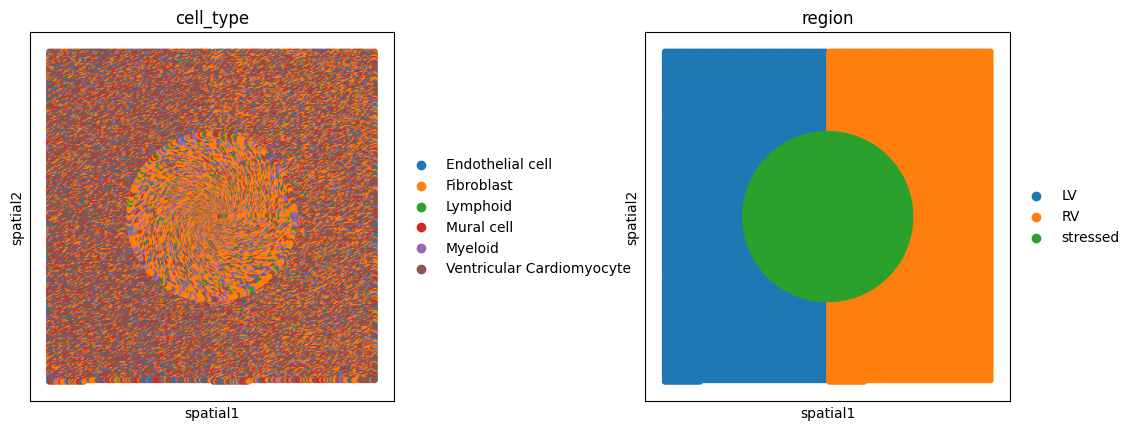

In [4]:
sc.pl.spatial(adata, color=["cell_type", 'region'], spot_size=20)

In [5]:
from anndata import AnnData
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

from src.cellina._spatial_utils import weighted_pseudobulks, spatial_neighbors

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing CSCDataset from `anndata.experimental` is deprecated. Import anndata.abc.CSCDataset instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge

In [6]:
n_neighbors = 50
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=True)

In [7]:
adata.obs['neighbor'] = adata.obsp['spatial_connectivities'].toarray()[0,:].astype(np.float32)

In [8]:
adata.var.index = adata.var['gene_name-new']

In [9]:
weighted_pseudobulks(
    adata,
    sp=adata.obsp['spatial_connectivities'],
    groupby="cell_type"
)

In [10]:
ndata = AnnData(adata.obsm['spatial_x'], obs=adata.obs, var=adata.uns['_spatial_var'], obsm=adata.obsm)

In [11]:
ndata.var['average'] = ndata.X.mean(axis=0)
ndata.var['std'] = ndata.X.std(axis=0)
ndata.var['cv'] = ndata.var['std'] / ndata.var['average']

In [12]:
ndata.var.set_index(0, inplace=True)

In [13]:
ndata.var.sort_values('cv', ascending=False, key=abs).head(5)
# TODO: need to move away from uniform representation of space

,average,std,cv
0,,,
Ventricular Cardiomyocyte_CLDN5,0.513454,0.499819,0.973445
Ventricular Cardiomyocyte_TBX1,0.513454,0.499819,0.973445
Ventricular Cardiomyocyte_IGLV6-57,0.513454,0.499819,0.973445
Ventricular Cardiomyocyte_TIAM1,0.513454,0.499819,0.973445
Ventricular Cardiomyocyte_FCGRT,0.513454,0.499819,0.973445


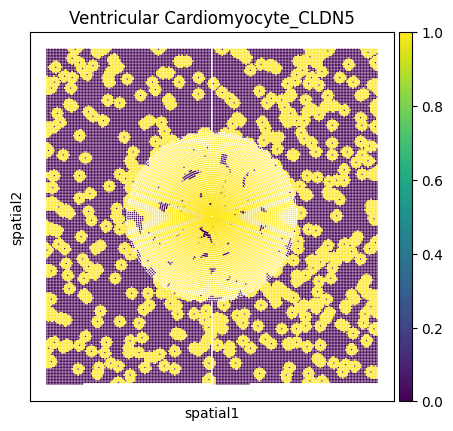

In [14]:
sc.pl.spatial(ndata, color=['Ventricular Cardiomyocyte_CLDN5'], spot_size=5)

In [15]:
adata.obsm['spatial_x'] = adata.obsm['spatial_x']

In [16]:
top_genes_idx = np.abs(np.argsort(ndata.var['cv']))[-1000:]
adata.obsm['spatial_x'] = adata.obsm['spatial_x'][:, top_genes_idx]

In [17]:
adata.obsm['spatial_x'].shape

(49800, 1000)

In [18]:
from cellina import CellinaModel

In [ ]:
CellinaModel.setup_anndata(adata, batch_key="batch", labels_key='cell_type', domains_key='region', spatial_obsm_key="spatial_x")
model = CellinaModel(adata, n_latent=20, classifier_lambda=1e8, discriminator_lambda=1e8)

INFO     Generating sequential column names                                                                        


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [20]:
model.train(max_epochs=200,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=25,
            early_stopping_monitor='validation_loss', # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            # default_root_dir='scvi_log/',
            plan_kwargs={'lr': 0.0001, 'weight_decay': 0.0001},
            enable_checkpointing=True,
            # callbacks=[
            #     SaveCheckpoint(monitor="validation_loss",
            #                    load_best_on_end=True,
            #                    dirpath=f'scvi_log/synthetic/',
            #                    filename='test1'),
            # ],
            batch_size=512,
            devices=[1]
            )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `n

Training:   0%|          | 0/200 [00:00<?, ?it/s]

/data/ddimitrov/repos/cellina/src/cellina/_cellina_module.py:329: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/data/ddimitrov/repos/cellina/src/cellina/_cellina_module.py:329: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/data/ddimitrov/repos/cellina/src/cellina/_cellina_module.py:329: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/data/ddimitrov/repos/cellina/src/cellina/_cellina_module.py:329: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/data/ddimitrov/repos/cellina/src/cellina/_cellina_module.py:329: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/data/ddimitrov/repos/cellina/src/cellina/_cellina_module.py:329: UserWarning: The value argument must be within the support of the distribution
  .log_prob(x)
/data/ddimitrov/repos/cellina/src/cellin

Monitored metric validation_loss did not improve in the last 25 records. Best score: 1317305600.000. Signaling Trainer to stop.


In [21]:
list(model.history_.keys())

['validation_loss',
 'elbo_validation',
 'reconstruction_loss_validation',
 'kl_local_validation',
 'kl_global_validation',
 'classifier_loss_validation',
 'classifier_accuracy_validation',
 'discriminator_loss_validation',
 'discriminator_accuracy_validation',
 'kl_weight',
 'adversarial_kappa',
 'discriminator_loss_train',
 'train_loss',
 'adversarial_loss_train',
 'elbo_train',
 'reconstruction_loss_train',
 'kl_local_train',
 'kl_global_train',
 'classifier_loss_train',
 'classifier_accuracy_train']

<Axes: xlabel='epoch'>

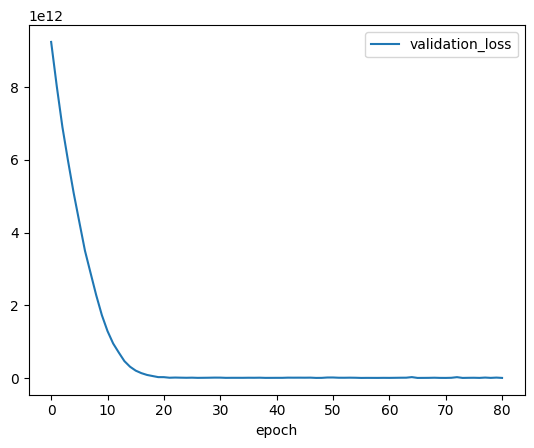

In [22]:
model.history_['validation_loss'].plot()

<Axes: xlabel='epoch'>

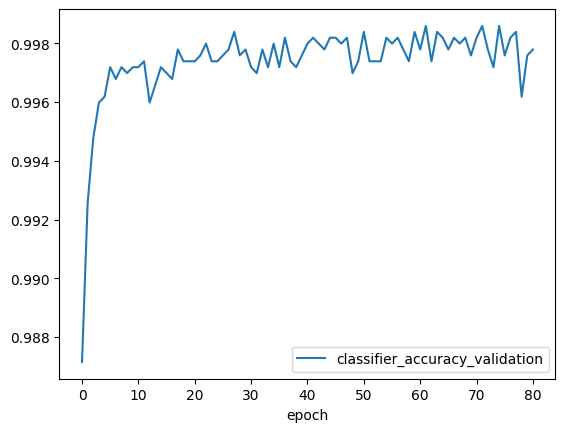

In [23]:
model.history_['classifier_accuracy_validation'].plot()

<Axes: xlabel='epoch'>

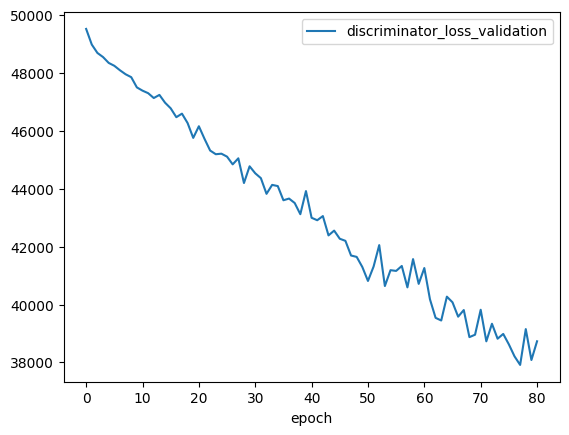

In [24]:
model.history_['discriminator_loss_validation'].plot()

<Axes: xlabel='epoch'>

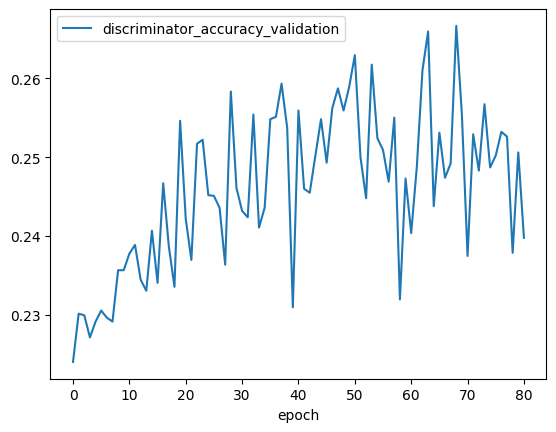

In [25]:
model.history_['discriminator_accuracy_validation'].plot()

In [26]:
adata.obsm['z'] = model.get_latent_representation(latent_key='z')

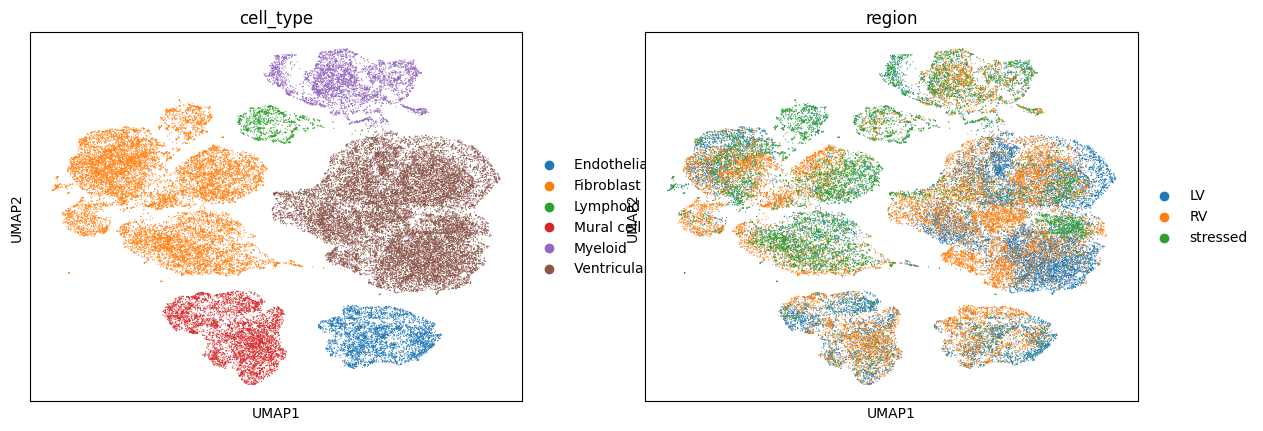

In [27]:
sc.pp.neighbors(adata, use_rep='z')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type', 'region'])

In [28]:
adata.obsm['z'].max()

5.933513

In [29]:
adata.obsm['s'] = model.get_latent_representation(latent_key='s')

In [30]:
adata.obsm['s'].max()

3.1738074

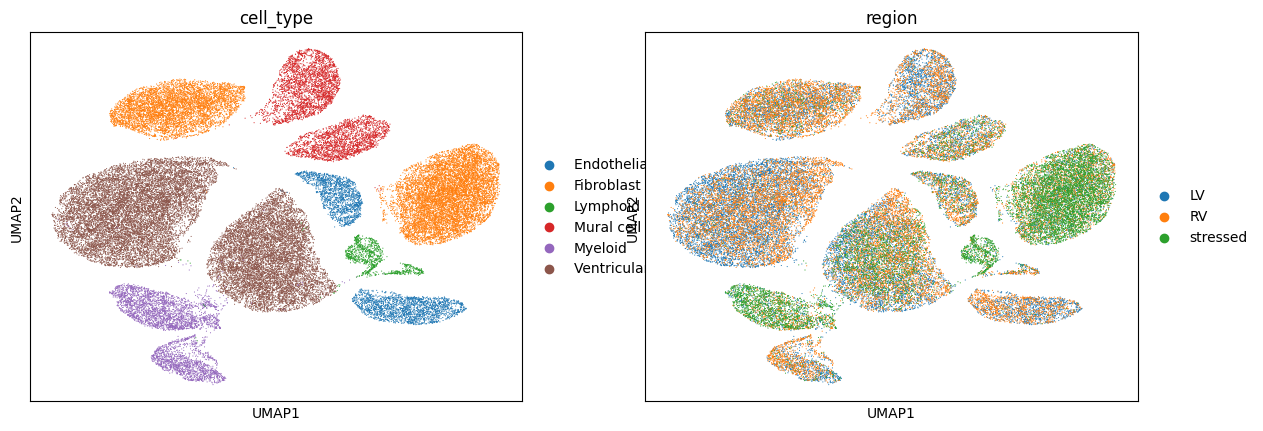

In [31]:
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata)
sc.pl.umap(adata, color=['cell_type', 'region'])